In [73]:
import kagglehub

path = kagglehub.dataset_download("buraktaci/multiple-sclerosis")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'multiple-sclerosis' dataset.
Path to dataset files: /kaggle/input/multiple-sclerosis


In [74]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix

In [75]:
def show_image(img, title="Input MRI Image"):
    plt.figure(figsize=(4,4))
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(title)
    plt.show()

In [76]:
def lpq(image, win_size):
    image = image.astype(np.float32)
    r = win_size // 2
    freq = 1.0 / win_size

    x = np.arange(-r, r + 1)
    w0 = np.ones_like(x)
    w1 = np.exp(-2j * np.pi * freq * x)

    filters = [
        np.outer(w0, w1),
        np.outer(w1, w0),
        np.outer(w1, w1),
        np.outer(w1, np.conj(w1))
    ]

    codes = np.zeros(image.shape, dtype=np.uint8)

    for i, f in enumerate(filters):
        real = cv2.filter2D(image, -1, np.real(f))
        imag = cv2.filter2D(image, -1, np.imag(f))
        codes |= ((real > 0).astype(np.uint8) << i)
        codes |= ((imag > 0).astype(np.uint8) << (i + 4))

    hist, _ = np.histogram(codes, bins=256, range=(0,256), density=True)
    return hist.astype(np.float32)


In [77]:
def exmplpq_features(img):
    img = cv2.resize(img, (224,224))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    feats = []
    for i in range(0,224,32):
        for j in range(0,224,32):
            patch = gray[i:i+32, j:j+32]
            feats.append(np.concatenate([
                lpq(patch,3),
                lpq(patch,5),
                lpq(patch,7)
            ]))

    feats.append(np.concatenate([
        lpq(gray,3),
        lpq(gray,5),
        lpq(gray,7)
    ]))

    return np.concatenate(feats)


In [78]:
BASE_DIR = "/root/.cache/kagglehub/datasets/buraktaci/multiple-sclerosis/versions/1/MS"

def is_axial(f): return "axial" in f.lower()
def is_sagittal(f): return "saggital" in f.lower() or "sagittal" in f.lower()

def load_hybrid_dataset(base_dir):
    X, y = [], []

    for folder in sorted(os.listdir(base_dir)):
        label = 1 if folder.lower().startswith("ms") else 0
        folder_path = os.path.join(base_dir, folder)

        print("Loading:", folder)

        for img_name in tqdm(os.listdir(folder_path)):
            if not img_name.lower().endswith((".png",".jpg",".jpeg")):
                continue

            img = cv2.imread(os.path.join(folder_path, img_name))
            if img is None:
                continue

            X.append(exmplpq_features(img))
            y.append(label)

    return np.array(X, dtype=np.float32), np.array(y)


In [79]:
X, y = load_hybrid_dataset(BASE_DIR)
print("Dataset shape:", X.shape)

Loading: Control Axial_crop


100%|██████████| 1002/1002 [01:54<00:00,  8.76it/s]


Loading: Control Saggital_crop


100%|██████████| 1014/1014 [01:29<00:00, 11.39it/s]


Loading: MS Axial_crop


100%|██████████| 650/650 [00:55<00:00, 11.76it/s]


Loading: MS Saggital_crop


100%|██████████| 761/761 [01:08<00:00, 11.13it/s]


Dataset shape: (3427, 38400)


In [80]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=600, random_state=42)
X_final = pca.fit_transform(X_scaled)


In [81]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NeighborhoodComponentsAnalysis



inca = NeighborhoodComponentsAnalysis(
    n_components=500,
    max_iter=50,
    tol=1e-4,
    random_state=42
)

X_sel = inca.fit_transform(X, y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sel)


In [82]:
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric="correlation",
    weights="distance"
)

In [83]:
def evaluate_knn(X, y):
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    acc = []

    for tr, te in skf.split(X, y):
        knn = KNeighborsClassifier(
            n_neighbors=5,
            metric="correlation",
            weights="distance"
        )
        knn.fit(X[tr], y[tr])
        acc.append(accuracy_score(y[te], knn.predict(X[te])))

    return np.mean(acc)

acc = evaluate_knn(X_scaled, y)
print(f"Hybrid Accuracy: {acc*100:.2f}%")

Hybrid Accuracy: 98.83%


In [84]:
def compute_metrics(X, y):
    y_true, y_pred = [], []
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    for tr, te in skf.split(X, y):
        knn = KNeighborsClassifier(
            n_neighbors=5,
            metric="correlation",
            weights="distance"
        )
        knn.fit(X[tr], y[tr])
        preds = knn.predict(X[te])

        y_true.extend(y[te])
        y_pred.extend(preds)

    TN, FP, FN, TP = confusion_matrix(y_true, y_pred).ravel()

    print("\n===== FINAL METRICS =====")
    print(f"Accuracy    : {accuracy_score(y_true,y_pred)*100:.2f}%")
    print(f"Sensitivity : {TP/(TP+FN)*100:.2f}%")
    print(f"Specificity : {TN/(TN+FP)*100:.2f}%")
    print(f"Precision   : {TP/(TP+FP)*100:.2f}%")
    print(f"F1-Score    : {(2*TP)/(2*TP+FP+FN)*100:.2f}%")
    print(f"MCC         : {((TP*TN)-(FP*FN))/np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN)):.3f}")

compute_metrics(X_scaled, y)


===== FINAL METRICS =====
Accuracy    : 98.83%
Sensitivity : 97.66%
Specificity : 99.65%
Precision   : 99.49%
F1-Score    : 98.57%
MCC         : 0.976


In [85]:

final_model = KNeighborsClassifier(
    n_neighbors=5,
    metric="correlation",
    weights="distance"
)
final_model.fit(X_scaled, y)


KNeighborsClassifier(metric='correlation', weights='distance')

In [86]:
def build_healthy_reference(X, y):
    # Use only healthy samples (label 0)
    healthy_features = X[y == 0]
    return np.mean(healthy_features, axis=0)


In [87]:
healthy_ref = build_healthy_reference(X, y)

In [88]:
def simple_brain_mask(gray):
    _, mask = cv2.threshold(
        gray, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask

In [89]:
BASE_DIR = "/root/.cache/kagglehub/datasets/buraktaci/multiple-sclerosis/versions/1/MS"

def build_healthy_reference_from_dataset(base_dir, max_images=50):
    features = []
    count = 0

    for folder in ["Control Axial_crop", "Control Saggital_crop"]:
        folder_path = os.path.join(base_dir, folder)

        for img_name in os.listdir(folder_path):
            if not img_name.lower().endswith((".png",".jpg",".jpeg")):
                continue

            img_path = os.path.join(folder_path, img_name)
            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.resize(img, (224,224))
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            for i in range(0,224,32):
                for j in range(0,224,32):
                    patch = gray[i:i+32, j:j+32]
                    features.append(np.concatenate([
                        lpq(patch,3),
                        lpq(patch,5),
                        lpq(patch,7)
                    ]))

            count += 1
            if count >= max_images:
                break

        if count >= max_images:
            break

    print(f"Healthy reference built using {count} images")

    return np.mean(features, axis=0)

In [90]:
def highlight_ms_regions(img_path, healthy_ref, view="axial", threshold=0.9):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    mask = simple_brain_mask(gray)
    heatmap = np.zeros((14,14))
    scores = []

    for i in range(0,224-32,16):
        for j in range(0,224-32,16):

            if mask[i+16, j+16] == 0:
                continue

            patch = gray[i:i+32, j:j+32]
            feat = np.concatenate([
                lpq(patch,3),
                lpq(patch,5),
                lpq(patch,7)
            ])

            score = np.linalg.norm(feat - healthy_ref)
            heatmap[i//16, j//16] = score
            scores.append(score)

    scores = np.array(scores)
    p95 = np.percentile(scores, 95)
    heatmap = np.clip(heatmap / p95, 0, 1)

    # View-specific suppression
    if view == "axial":
        heatmap[:, 3:4] *= 0.3
    elif view == "sagittal":
        heatmap[:4, :] *= 0.15
        heatmap[5:, :] *= 0.3

    # Lesion mask
    lesion_mask = (heatmap >= threshold).astype(np.uint8)

    # Resize + smooth (visual only)
    heatmap_vis = cv2.resize(heatmap, (224,224))
    heatmap_vis = cv2.GaussianBlur(heatmap_vis, (21,21), 0)

    # ===== VISUALIZATION =====
    import matplotlib.pyplot as plt
    plt.figure(figsize=(6,6))
    plt.imshow(gray, cmap="gray")
    plt.imshow(heatmap_vis, cmap="jet", alpha=0.45)
    plt.title("Marked MS Lesion Regions")
    plt.axis("off")
    plt.show()

    # ===== RETURN FOR STATISTICS =====
    return heatmap, lesion_mask, scores

In [91]:
healthy_ref = build_healthy_reference_from_dataset(BASE_DIR)

Healthy reference built using 50 images


In [92]:
def predict_single_image(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (224,224))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    show_image(gray, "Test MRI Image")

    feat = exmplpq_features(img).reshape(1, -1)
    feat = inca.transform(feat)
    feat = scaler.transform(feat)

    pred = final_model.predict(feat)[0]

    if pred == 1:
        print("🧠 Prediction: MULTIPLE SCLEROSIS (MS)")
    else:
        print("🧠 Prediction: HEALTHY CONTROL")

In [93]:
def compute_lesion_statistics(heatmap, lesion_mask, scores):
    total_patches = heatmap.size
    lesion_patches = np.sum(lesion_mask)

    lesion_percentage = lesion_patches / total_patches * 100
    mean_abnormality = np.mean(scores)
    max_abnormality = np.max(scores)

    mu = np.mean(heatmap)
    sigma = np.std(heatmap)

    soft_thresh = mu + 1.0 * sigma   # 1σ above mean
    soft_lesion_percentage = np.sum(heatmap >= soft_thresh) / heatmap.size * 100

    print("===== Quantitative Lesion Statistics =====")
    print(f"Total patches            : {total_patches}")
    print(f"Hard lesion patches      : {lesion_patches}")
    print(f"Hard lesion burden (%)   : {lesion_percentage:.2f}%")
    print(f"Soft abnormality (%)     : {soft_lesion_percentage:.2f}%")
    print(f"Mean abnormality         : {mean_abnormality:.3f}")
    print(f"Max abnormality          : {max_abnormality:.3f}")

    return {
        "hard_lesion_percentage": lesion_percentage,
        "soft_abnormality_percentage": soft_lesion_percentage,
        "mean_abnormality": mean_abnormality,
        "max_abnormality": max_abnormality
    }

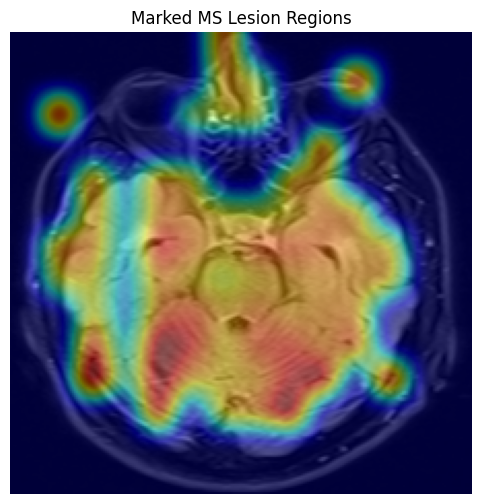

===== Quantitative Lesion Statistics =====
Total patches            : 196
Hard lesion patches      : 5
Hard lesion burden (%)   : 2.55%
Soft abnormality (%)     : 28.06%
Mean abnormality         : 0.096
Max abnormality          : 0.204


In [94]:
test_img = "/content/A1 (1).png"   # <-- replace with your axial image path

heatmap, lesion_mask, scores = highlight_ms_regions(
    test_img,
    healthy_ref,
    view="axial",
    threshold=0.90
)

stats = compute_lesion_statistics(heatmap, lesion_mask, scores)


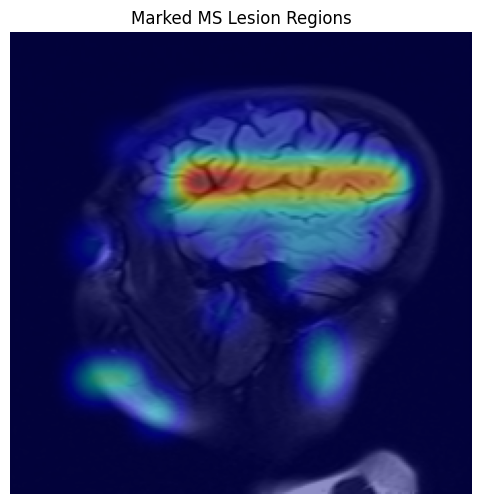

===== Quantitative Lesion Statistics =====
Total patches            : 196
Hard lesion patches      : 0
Hard lesion burden (%)   : 0.00%
Soft abnormality (%)     : 9.18%
Mean abnormality         : 0.100
Max abnormality          : 0.177


In [95]:
test_img = "/content/S1 (104).png"

heatmap, lesion_mask, scores = highlight_ms_regions(
    test_img,
    healthy_ref,
    view="sagittal",   # or "axial" depending on image
    threshold=0.92
)

stats = compute_lesion_statistics(heatmap, lesion_mask, scores)


In [96]:
import joblib

os.makedirs("saved_model", exist_ok=True)


np.save("saved_model/healthy_ref.npy", healthy_ref)

joblib.dump(inca, "saved_model/inca_model.pkl")

joblib.dump(scaler, "saved_model/scaler.pkl")


joblib.dump(knn, "saved_model/knn_model.pkl")

print("✅ Model artifacts saved successfully!")

✅ Model artifacts saved successfully!


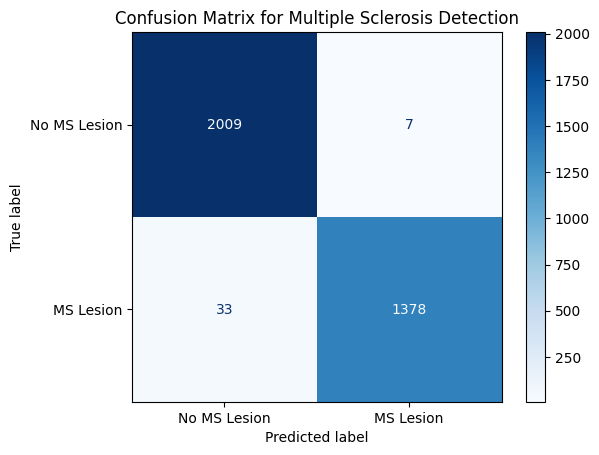

In [98]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# Re-run the cross-validation to get y_test (actual) and y_pred (predictions)
y_test = []
y_pred = []
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for tr, te in skf.split(X_scaled, y):
    knn_fold = KNeighborsClassifier(
        n_neighbors=5,
        metric="correlation",
        weights="distance"
    )
    knn_fold.fit(X_scaled[tr], y[tr])
    preds = knn_fold.predict(X_scaled[te])

    y_test.extend(y[te])
    y_pred.extend(preds)

# Ensure y_test and y_pred are numpy arrays for confusion_matrix
y_test = np.array(y_test)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No MS Lesion", "MS Lesion"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix for Multiple Sclerosis Detection")
plt.show()